# Legal-SBERT

Labeling clusters based on dictionaries...
Generating Visualizations...


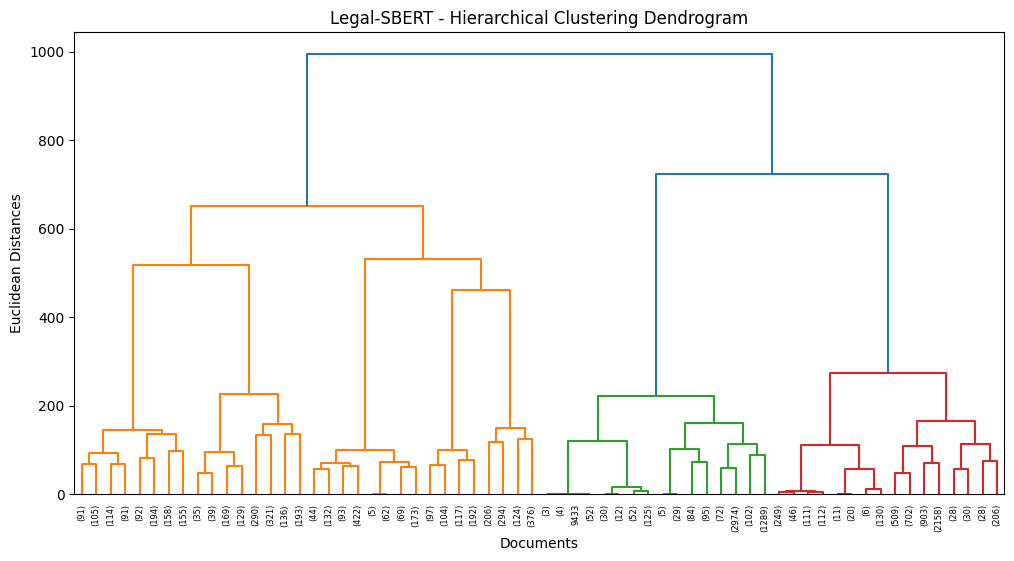

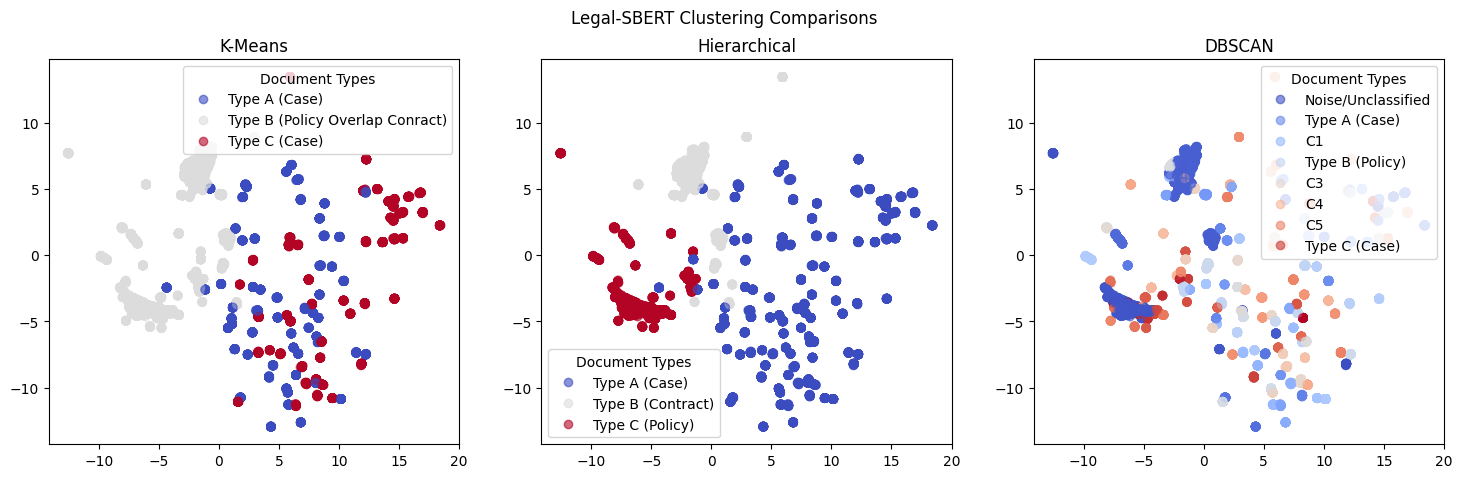

In [ ]:
import pandas as pdd
import numpy as np
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
import scipy.cluster.hierarchy as sch
import umap

# ==========================================
# 1. Helper Function for Cluster Analysis
# ==========================================
"""def analyze_clusters(df, text_col, embeddings, labels, algo_name):
    unique_labels = set(labels)
    valid_clusters = [lbl for lbl in unique_labels if lbl != -1]
    
    if len(valid_clusters) > 1:
        sil = silhouette_score(embeddings, labels)
        dbi = davies_bouldin_score(embeddings, labels)
    else:
        sil, dbi = "N/A", "N/A"
 
    print(f"\n{'='*15} {algo_name} {'='*15}")
    print(f"Silhouette Score     : {sil if isinstance(sil, str) else f'{sil:.4f}'}")
    print(f"Davies-Bouldin Index : {dbi if isinstance(dbi, str) else f'{dbi:.4f}'}")
    print("-" * 45)
    
    for cluster_id in sorted(list(unique_labels)):
        cluster_docs = df[labels == cluster_id][text_col].astype(str).tolist()
        doc_count = len(cluster_docs)
        if cluster_id == -1:
            print(f"Cluster -1 (Noise)  : {doc_count} documents")
            continue
        try:
            vectorizer = TfidfVectorizer(max_features=5, stop_words='english')
            vectorizer.fit(cluster_docs)
            top_keywords = ", ".join(vectorizer.get_feature_names_out())
        except ValueError:
            top_keywords = "Not enough distinct words"
        print(f"Cluster {cluster_id}         : {doc_count} docs | Keywords: [{top_keywords}]")
    print("==================================================\n")
 
# ==========================================
# 2. Load Data & Generate Embeddings
# ==========================================
print("Loading data...")
df= pd.read_excel("/Users/jannatunnesajerin/DATA SCIENCE PAPER WORK UNSPERVIDED LEARNING/processed_corpus.xlsx") 
df = df.dropna(subset=['text'])
documents = df['text'].astype(str).tolist()
 
print("Encoding documents with Legal-SBERT...")
legal_sbert_model = SentenceTransformer('nlpaueb/legal-bert-base-uncased')
X_legal_raw = legal_sbert_model.encode(documents, show_progress_bar=True)
 
# ==========================================
# 3. UMAP Dimensionality Reduction
# ==========================================
print("Reducing dimensions with UMAP...")
umap_reducer = umap.UMAP(n_neighbors=15, n_components=5, metric='cosine', random_state=42)
X_legal = umap_reducer.fit_transform(X_legal_raw)
 
# ==========================================
# 4. Apply Clustering Algorithms
# ==========================================
num_clusters = 3
 
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
df['legal_kmeans'] = kmeans.fit_predict(X_legal)
analyze_clusters(df, 'text', X_legal, df['legal_kmeans'], "K-MEANS")
 
hierarchical = AgglomerativeClustering(n_clusters=num_clusters)
df['legal_hierarchical'] = hierarchical.fit_predict(X_legal)
analyze_clusters(df, 'text', X_legal, df['legal_hierarchical'], "HIERARCHICAL")
 
dbscan = DBSCAN(eps=0.5, min_samples=5) 
df['legal_dbscan'] = dbscan.fit_predict(X_legal)
analyze_clusters(df, 'text', X_legal, df['legal_dbscan'], "DBSCAN")"""
 
# ==========================================
# 5. Labeling the Clusters (Separate Mappings)
# ==========================================
print("Labeling clusters based on dictionaries...")
 
# UPDATE THESE DICTIONARIES BASED ON YOUR TERMINAL OUTPUT
kmeans_names = {
    0: "Type A (Case)", 1: "Type B (Policy Overlap Conract)", 
    2: "Type C (Case)"
}
 
hierarchical_names = {
    0: "Type A (Case)", 1: "Type B (Contract)", 
    2: "Type C (Policy)"
}
 
dbscan_names = {
    -1: "Noise/Unclassified",
    0: "Type A (Case)", 2: "Type B (Policy)",6: "Type C (Case)"
}
 
df['kmeans_type'] = df['legal_kmeans'].map(kmeans_names)
df['hierarchical_type'] = df['legal_hierarchical'].map(hierarchical_names)
df['dbscan_type'] = df['legal_dbscan'].map(lambda x: dbscan_names.get(x, f"Cluster {x}"))
 
# ==========================================
# 6. Visualizations (With Custom Legends)
# ==========================================
print("Generating Visualizations...")
 
plt.figure(figsize=(12, 6))
plt.title("Legal-SBERT - Hierarchical Clustering Dendrogram")
linkage_matrix = sch.linkage(X_legal, method='ward')
sch.dendrogram(linkage_matrix, truncate_mode='level', p=5)
plt.xlabel("Documents")
plt.ylabel("Euclidean Distances")
plt.show()
 
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_legal)
 
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Legal-SBERT Clustering Comparisons')
 
scatter0 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=df['legal_kmeans'], cmap='coolwarm', alpha=0.6)
axes[0].set_title('K-Means')
handles0, _ = scatter0.legend_elements()
labels0 = [kmeans_names.get(c, f"C{c}") for c in sorted(df['legal_kmeans'].unique())]
axes[0].legend(handles0, labels0, title="Document Types")
 
scatter1 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=df['legal_hierarchical'], cmap='coolwarm', alpha=0.6)
axes[1].set_title('Hierarchical')
handles1, _ = scatter1.legend_elements()
labels1 = [hierarchical_names.get(c, f"C{c}") for c in sorted(df['legal_hierarchical'].unique())]
axes[1].legend(handles1, labels1, title="Document Types")
 
scatter2 = axes[2].scatter(X_pca[:, 0], X_pca[:, 1], c=df['legal_dbscan'], cmap='coolwarm', alpha=0.6)
axes[2].set_title('DBSCAN')
handles2, _ = scatter2.legend_elements()
labels2 = [dbscan_names.get(c, f"C{c}") for c in sorted(df['legal_dbscan'].unique())]
axes[2].legend(handles2, labels2, title="Document Types")
 
plt.show()
 